In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("E:/project/data/processed/nav_history_clean.csv")
performance = pd.read_csv("E:/project/data/processed/scheme_performance_clean.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [5]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
var_report = []
nav = nav.sort_values(["amfi_code", "date"])
for code in nav["amfi_code"].unique():
    fund = nav[nav["amfi_code"] == code]
    returns = fund["daily_return"].dropna()

    if returns.empty:
        continue

    var95 = np.percentile(returns, 5)
    cvar95 = returns[returns <= var95].mean()
    scheme_name = performance.loc[performance["amfi_code"] == code,"scheme_name"].values[0]

    var_report.append({
        "amfi_code": code,
        "scheme_name": scheme_name,
        "VaR_95": round(var95,6),
        "CVaR_95": round(cvar95,6)})

var_cvar = pd.DataFrame(var_report)
var_cvar.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [7]:
var_cvar.to_csv("E:/project/data/processed/var_cvar_report.csv",index=False)


---

Top 5 Funds:
                                     scheme_name  sharpe_ratio
14      ICICI Pru Liquid Fund - Regular - Growth          7.68
23          Kotak Liquid Fund - Regular - Growth          6.18
30           ABSL Liquid Fund - Regular - Growth          5.14
9   HDFC Short Term Debt Fund - Regular - Growth          1.84
4   SBI Magnum Gilt Fund - Regular Plan - Growth          1.52


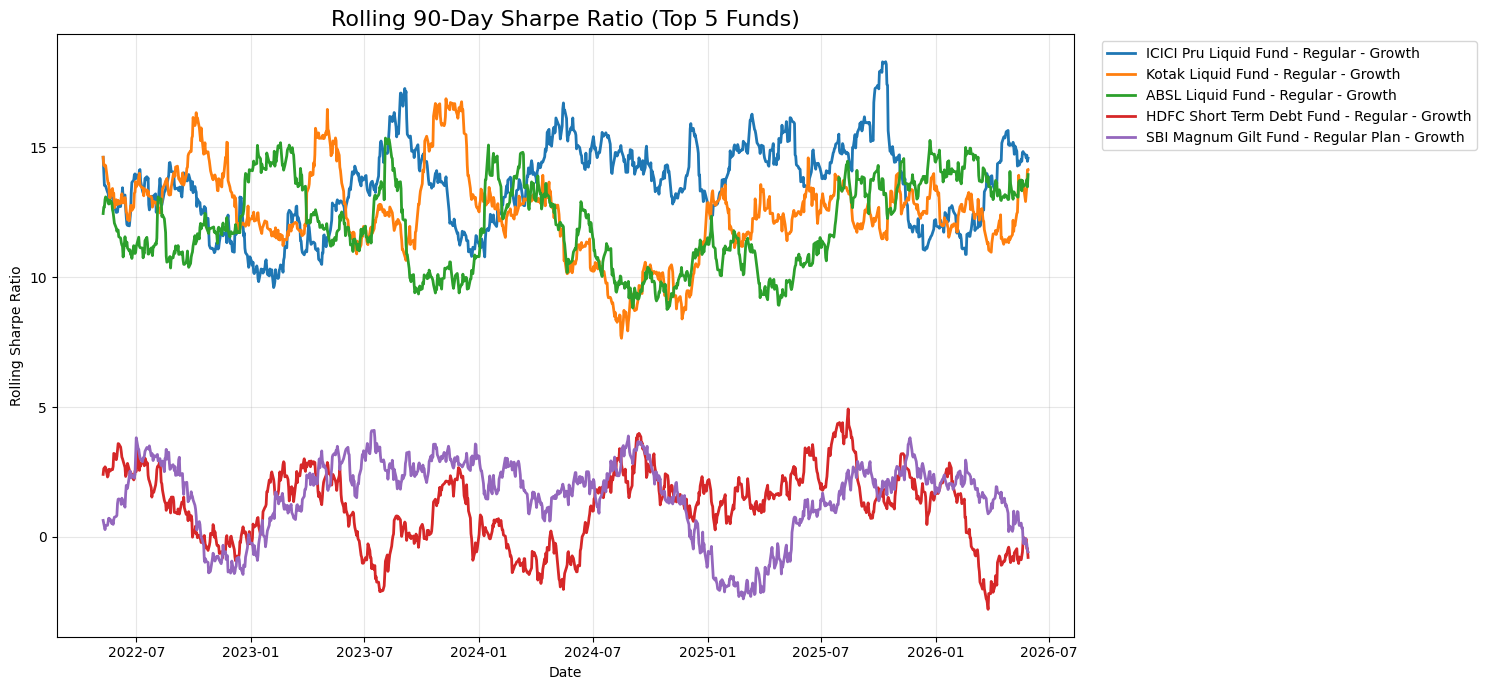

In [9]:
import os

nav = pd.read_csv("E:/project/data/processed/nav_history_clean.csv")
performance = pd.read_csv("E:/project/data/processed/scheme_performance_clean.csv")
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

if "daily_return" not in nav.columns:
    nav["daily_return"] = (nav.groupby("amfi_code")["nav"].pct_change())

top5 = (performance.sort_values("sharpe_ratio", ascending=False).head(5))

print("Top 5 Funds:")
print(top5[["scheme_name", "sharpe_ratio"]])

save_folder = "E:/project/reports/charts"
os.makedirs(save_folder, exist_ok=True)
plt.figure(figsize=(15,7))
plotted = False

for _, row in top5.iterrows():
    code = row["amfi_code"]
    name = row["scheme_name"]
    fund = nav[nav["amfi_code"] == code].copy()

    if fund.empty:
        continue

    fund = fund.sort_values("date")
    fund["daily_return"] = fund["nav"].pct_change()
    fund["rolling_sharpe"] = (fund["daily_return"].rolling(window=90, min_periods=90).mean() / fund["daily_return"].rolling(window=90, min_periods=90).std()) * np.sqrt(252)
    fund = fund.dropna(subset=["rolling_sharpe"])

    if fund.empty:
        continue

    plt.plot(
        fund["date"],
        fund["rolling_sharpe"],
        linewidth=2,
        label=name)

    plotted = True


if plotted:

    plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)", fontsize=16)
    plt.xlabel("Date")
    plt.ylabel("Rolling Sharpe Ratio")
    plt.grid(alpha=0.3)
    plt.legend(loc="upper left",bbox_to_anchor=(1.02,1))
    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, "rolling_sharpe_chart.png"),dpi=300,bbox_inches="tight")
    plt.show()


---

In [10]:
transactions = pd.read_csv(r"E:\Project\data\processed\investor_transactions_clean.csv")
fund_master = pd.read_csv(r"E:\Project\data\processed\fund_master_clean.csv")


transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])


first_transaction = (transactions.groupby("investor_id")["transaction_date"].min().reset_index())
first_transaction["cohort_year"] = first_transaction["transaction_date"].dt.year


transactions = transactions.merge(
    first_transaction[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left")

top_fund = (transactions.groupby(["cohort_year", "amfi_code"]).size().reset_index(name="count"))
top_fund = (top_fund.sort_values(["cohort_year", "count"], ascending=[True, False]).drop_duplicates("cohort_year"))

top_fund = top_fund.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left")


cohort = (transactions.groupby("cohort_year").agg(Investors=("investor_id", "nunique"),Avg_SIP_Amount=("amount_inr", "mean"),Total_Investment=("amount_inr", "sum")).reset_index())


cohort = cohort.merge(
    top_fund[["cohort_year", "scheme_name"]],
    on="cohort_year",
    how="left")

cohort.rename(columns={"scheme_name": "Top_Fund_Preference"},inplace=True)

cohort["Avg_SIP_Amount"] = cohort["Avg_SIP_Amount"].round(2)
cohort["Total_Investment"] = cohort["Total_Investment"].round(2)

save_path = r"E:\Project\data\processed\cohort_analysis.csv"
cohort.to_csv(save_path, index=False)



---

In [11]:
transactions = pd.read_csv( r"E:\Project\data\processed\investor_transactions_clean.csv")
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])


sip = transactions[transactions["transaction_type"] == "SIP"].copy()
sip = sip.sort_values(["investor_id", "transaction_date"])


sip["gap_days"] = (sip.groupby("investor_id")["transaction_date"].diff().dt.days)

summary = (sip.groupby("investor_id").agg(
        SIP_Count=("transaction_date", "count"),
        Avg_Gap_Days=("gap_days", "mean"),
        Total_Investment=("amount_inr", "sum"),
        Avg_SIP_Amount=("amount_inr", "mean")).reset_index())

summary = summary[summary["SIP_Count"] >= 6]
summary["Status"] = np.where(summary["Avg_Gap_Days"] > 35,"At Risk","Active")
summary["Avg_Gap_Days"] = summary["Avg_Gap_Days"].round(2)
summary["Avg_SIP_Amount"] = summary["Avg_SIP_Amount"].round(2)
summary["Total_Investment"] = summary["Total_Investment"].round(2)

save_path = r"E:\Project\data\processed\sip_continuity_report.csv"

summary.to_csv(save_path,index=False)

---

In [12]:
portfolio = pd.read_csv( r"E:\Project\data\processed\portfolio_holdings_clean.csv")
performance = pd.read_csv(r"E:\Project\data\processed\scheme_performance_clean.csv")

portfolio["weight"] = portfolio["weight_pct"] / 100

hhi = (portfolio.groupby("amfi_code").agg(HHI=("weight", lambda x: np.sum(x**2))).reset_index())

hhi = hhi.merge(performance[["amfi_code","scheme_name","category"]],on="amfi_code",how="left")
equity = hhi[hhi["category"].str.contains("Equity",case=False,na=False)].copy()

def classify(hhi):

    if hhi < 0.15:
        return "Highly Diversified"

    elif hhi < 0.25:
        return "Moderately Concentrated"

    else:
        return "Highly Concentrated"

equity["Concentration"] = equity["HHI"].apply(classify)
equity = equity.sort_values("HHI",ascending=False)

save_path = ( r"E:\Project\data\processed\sector_hhi_report.csv")
equity.to_csv(save_path,index=False)


## Insight 1 – Historical VaR & CVaR

The Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR) analysis identified funds with the highest downside risk. Funds having more negative VaR and CVaR values are exposed to larger losses during adverse market conditions. These funds may be suitable only for investors with a higher risk tolerance.

---

## Insight 2 – Rolling 90-Day Sharpe Ratio

The Rolling 90-Day Sharpe Ratio showed how the risk-adjusted performance of the selected mutual funds changed over time. Liquid funds maintained relatively stable Sharpe Ratios, while other funds experienced greater fluctuations due to changing market conditions. Higher Sharpe values indicate superior returns relative to the risk taken.

---

## Insight 3 – Investor Cohort Analysis

Investor Cohort Analysis revealed the investment behaviour of investors based on the year of their first investment. Recent investor cohorts contributed higher investment amounts and showed increasing participation in mutual fund investments. The analysis also identified the most preferred mutual fund for each cohort.

---

## Insight 4 – SIP Continuity Analysis

The SIP Continuity Analysis evaluated investor consistency by calculating the average gap between SIP transactions. Investors with an average gap exceeding 35 days were classified as **At Risk**, while the remaining investors were classified as **Active**. This helps identify investors who may discontinue their SIP investments and require timely engagement.

---

## Insight 5 – Sector HHI Concentration

The Herfindahl–Hirschman Index (HHI) measured portfolio concentration using sector allocation weights. Equity funds with higher HHI values were more concentrated in a limited number of sectors and therefore carried higher sector-specific risk. Funds with lower HHI values demonstrated better diversification and reduced concentration risk.

